# 📘Домашнє завдання №10 Лінійна регресія

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW10

Основні метрики
* MAE - mean absolute error (середня абсолютна похибка)
$$ MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i| $$
* MSE - mean squared error (середньоквадратичне відхилення)
$$ MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$
* RMSE - root mean squared error (корінь середньоквадратичного відхилення)
$$ RMSE = \sqrt{MSE} $$
* R² - coefficient of determination (коефіцієнт детермінації)
$$ R^2 = 1 - \frac{MSE}{\sum_{i=1}^{N} (y_i - \bar{y})^2} $$

Дано датасет:
| Площа (м²) | Кількість кімнат | Ціна ($ тис.) |
|----------|-------|----------------|
| 40       | 1     | 120            |
| 45       | 2     | 135            |
| 50       | 2     | 150            |
| 55       | 2     | 165            |
| 60       | 3     | 180            |
| 65       | 3     | 195            |
| 70       | 3     | 205            |
| 75       | 3     | 215            |
| 80       | 3     | 225            |
| 85       | 4     | 240            |
| 90       | 4     | 255            |
| 95       | 4     | 270            |
| 100      | 4     | 285            |
| 105      | 4     | 300            |
| 110      | 5     | 315            |
| 115      | 5     | 330            |
| 120      | 5     | 345            |
| 125      | 5     | 360            |
| 130      | 6     | 380            |
| 140      | 6     | 410            |

**Завдання**:
1. Побудуйте просту лінійну регресію - використайте тільки площу (м²) для передбачення ціни, обчисліть MSE.
2. Якою буде ціна для квартири 90 м²?
3. Використайте площу та кількість кімнат. Як змінииться MSE?
4. Побудуйте графік і проведіть лінію регресії:
   - X: площа
   - Y: ціна
5. Побудуйте Ridge та Lasso Regression, порівняйте з моделлю, отриманою в п.3.
  


In [5]:
import numpy as np
import pandas as pd
import jinja2
from pandas.io.formats.style import Styler


class Reporter:
    """
    Class for collecting and printing data in tabular form
    """

    def __init__(self, attribute_col: str = "Attribute", result_col: str = "Result"):
        self._border_sign = "#"
        self._hor_split_sign = "~"
        self._ver_split_sign = "|"
        self._tolerance = 4
        self._max_len_lf: int = 0
        self._max_len_rt: int = 0
        self._data_list: list[tuple[str, str]] = []
        self.attribute_col = attribute_col
        self.result_col = result_col

    @property
    def max_len_lf(self) -> int:
        """Maximum left column width (the 1st column)"""
        return self._max_len_lf

    @property
    def max_len_rt(self) -> int:
        """Maximum right column width (the 2nd column)"""
        return self._max_len_rt

    @property
    def data_list(self) -> list[tuple[str, str]]:
        """The list of data to be printed"""
        return self._data_list

    @property
    def border_sign(self) -> str:
        """Character used for the outside table border"""
        return self._border_sign

    @border_sign.setter
    def border_sign(self, value: str) -> None:
        self._border_sign = value

    @property
    def hor_split_sign(self) -> str:
        """Character used for horizontal splitter in tabular form"""
        return self._hor_split_sign

    @hor_split_sign.setter
    def hor_split_sign(self, value: str) -> None:
        self._hor_split_sign = value

    @property
    def ver_split_sign(self) -> str:
        """Character used for vertical splitter in tabular form"""
        return self._ver_split_sign

    @ver_split_sign.setter
    def ver_split_sign(self, value: str) -> None:
        self._ver_split_sign = value

    @property
    def tolerance(self) -> int:
        """Number of digits after the floating point"""
        return self._tolerance

    @tolerance.setter
    def tolerance(self, value: int) -> None:
        self._tolerance = value

    @property
    def attribute_col(self) -> str:
        """Name of the attribute (the 1st column)"""
        return self._attribute_col

    @attribute_col.setter
    def attribute_col(self, value: str) -> None:
        array_str_key = value.splitlines()
        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))
        self._attribute_col = value

    @property
    def result_col(self) -> str:
        """Name of the result (the 2nd column)"""
        return self._result_col

    @result_col.setter
    def result_col(self, value: str) -> None:
        array_str_value = value.splitlines()
        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))
        self._result_col = value

    def format_value(self, value: float) -> str:
        """
        Format value to string
        :param value: input value
        :return: string of the value
        """
        return f"{value:.{self.tolerance}f}"

    def format_matrix(self, matrix: np.ndarray) -> str:
        """
        Formatting matrix into string
        :param matrix: input matrix
        :return: string of the matrix
        """
        return np.array2string(matrix, precision=self.tolerance)

    def add_item(self, key: str, value: str) -> None:
        """
        Form the report data that consist multi strings
        :param key: attribute
        :param value: result
        """
        array_str_key = key.splitlines()
        array_str_value = value.splitlines()

        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))

        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))

        self._data_list.append((key, value))

    def _print_line_splitter(self, sign: str = "-") -> None:
        """
        Print line splitter
        """
        print(sign * (self.max_len_lf + self.max_len_rt + 5))

    def _print_multi_string(self, row: tuple[str, str]) -> None:
        """
        Print the multi-string
        :param row: tuple of data
        """
        array_str_key = row[0].splitlines()
        array_str_value = row[1].splitlines()
        num_str = max(len(array_str_key), len(array_str_value))

        for index in range(num_str):
            if index < len(array_str_key):
                left_str = f"{f"{array_str_key[index]}":<{self.max_len_lf}}"
            else:
                left_str = f"{f" ":<{self.max_len_lf}}"

            if index < len(array_str_value):
                right_str = f"{f"{array_str_value[index]:<{self.max_len_rt}}"}"
            else:
                right_str = f"{f" ":<{self.max_len_rt}}"

            print(f" {left_str} {self.ver_split_sign} {right_str}")

    def refresh_table_config(self) -> None:
        """
        Refresh table configuration, like line lengths
        :return:
        """
        self._max_len_lf = 0
        self._max_len_rt = 0

        self.attribute_col = self.attribute_col
        self.result_col = self.result_col

        temp_data_list = self.data_list
        self._data_list = []
        for temp_data in temp_data_list:
            self.add_item(temp_data[0], temp_data[1])

    def print_report(self) -> None:
        """
        Print report data
        """
        self._print_line_splitter(self.border_sign)
        self._print_multi_string((self.attribute_col, self.result_col))
        self._print_line_splitter(self.border_sign)
        for item_data in self.data_list[0:-1]:
            self._print_multi_string(item_data)
            self._print_line_splitter("~")
        self._print_multi_string(self.data_list[-1])
        self._print_line_splitter(self.border_sign)

    def print_refreshed_report(self) -> None:
        """
        Print report data with a refreshing table
        """
        self.refresh_table_config()
        self.print_report()

    def get_pd_report(self) -> Styler:
        """
        Generate report data using pandas dataframe
        """
        df_data_list = pd.DataFrame(self.data_list, columns=[self.attribute_col, self.result_col])
        pd.set_option('display.max_colwidth', None)
        df_data_list = (df_data_list.style.hide(axis='index')
        .set_properties(**{
            'text-align': 'left',
            'white-space': 'pre-wrap',
            'border': '1px solid lightgrey'
        }).set_table_styles([  # type: ignore
            {"selector": "th", "props": [("text-align", "left")]}
        ]))
        return df_data_list

    def print_pd_report(self) -> None:
        """
        Print report data using pandas dataframe
        """
        df_data_list = self.get_pd_report()
        display(df_data_list)


In [1]:
import pandas as pd

# Input data
mae_name = "neg_mean_absolute_error"
mse_name = "neg_mean_squared_error"
rmse_name = "neg_root_mean_squared_error"
r2_name = "r2"
scorings = {
    'mae': mae_name,
    'mse': mse_name,
    'rmse': rmse_name,
    'r2': r2_name,
}

data = {
    "area": [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 140],
    "rooms": [1, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6],
    "price": [120, 135, 150, 165, 180, 195, 205, 215, 225, 240, 255, 270, 285, 300, 315, 330, 345, 360, 380, 410],
}

# Solution
df = pd.DataFrame(data)

# Print results
display(df)

,area,rooms,price
0,40,1,120
1,45,2,135
2,50,2,150
3,55,2,165
4,60,3,180
5,65,3,195
6,70,3,205
7,75,3,215
8,80,3,225
9,85,4,240


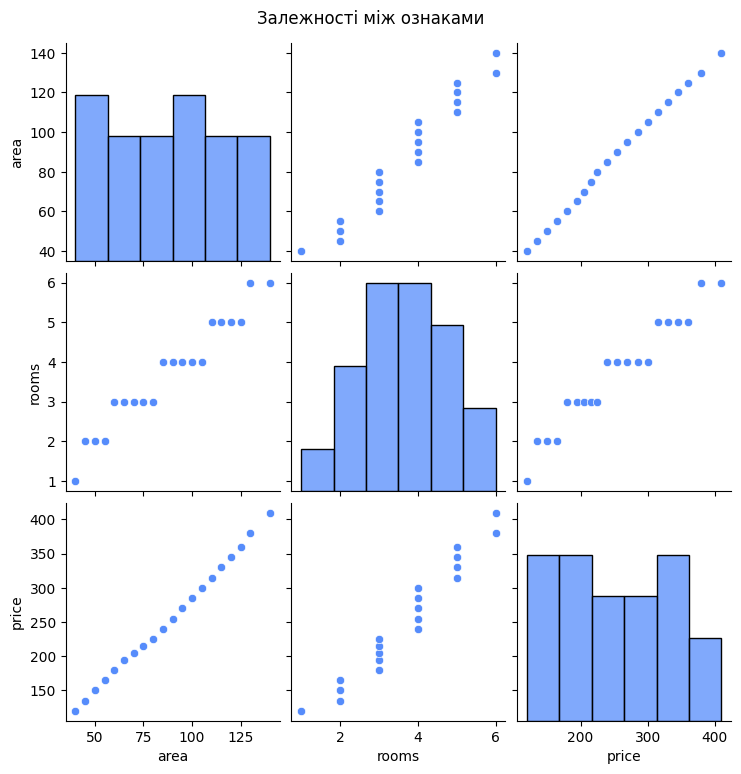

In [2]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
area_col_name = "area"
rooms_col_name = "rooms"
price_col_name = "price"

# Solution
sns.pairplot(data=df)

plt.suptitle("Залежності між ознаками", y=1.025)

plt.show()

## Завдання 1. Фільтрація покупок

Побудуйте просту лінійну регресію - використайте тільки площу (м²) для передбачення ціни, обчисліть MSE.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

# Input data
n_splits = 5
X_area = df[area_col_name].values.reshape(-1, 1)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
model_simple = LinearRegression()
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scores_simple = cross_validate(model_simple, X_area, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_simple["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_simple["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_simple["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_simple["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_simple["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_simple["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_simple["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_simple["test_r2"].mean()))

# Print results
rp.print_pd_report()

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[ 3.0133 29.7247 16.8878 38.7386 13.5454]
Mean MSE,20.3820
RMSE scores,[1.7359 5.452 4.1095 6.224 3.6804]
Mean RMSE,4.2404
MAE scores,[1.5191 5.3269 3.2309 5.7236 3.1562]
Mean MAE,3.7913
R² scores,[0.9997 0.9802 0.9978 0.9946 0.9928]
Mean R²,0.9930
